# Thử nghiệm bổ sung và tối ưu hóa mô hình Abalone

Notebook này triển khai giai đoạn `Tuning & Optimization` theo yêu cầu đề bài. Trọng tâm là tạo ra bằng chứng cải thiện so với baseline đã có ở notebook 03 và notebook 04.

## 1. Năm phương án cải thiện được thực hiện

Notebook này áp dụng ít nhất 5 hướng cải thiện khác nhau:

1. So sánh hai phiên bản dữ liệu cho nhóm mô hình nhạy với scale: `standard_scaled` và `robust_log_scaled`.
2. Tuning siêu tham số bằng `RandomizedSearchCV` cho **toàn bộ 10 mô hình hồi quy bắt buộc**.
3. Chọn phiên bản dữ liệu tốt hơn cho từng mô hình trước khi tuning.
4. Kết hợp dự đoán bằng `Weighted Average Ensemble` cho các mô hình optimized mạnh nhất.
5. Xây dựng `Stacking` đơn giản bằng meta-model `Ridge` trên OOF predictions của các mô hình optimized hàng đầu.

## 2. Chuẩn bị thư viện

In [18]:
import json
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_predict
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import LinearSVR, SVR
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Load dữ liệu và kết quả baseline

In [19]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'outputs' / 'models'
METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train_encoded_df = pd.read_csv(PROCESSED_DIR / 'abalone_train_encoded.csv')
test_encoded_df = pd.read_csv(PROCESSED_DIR / 'abalone_test_encoded.csv')
train_standard_df = pd.read_csv(PROCESSED_DIR / 'abalone_train_standard.csv')
test_standard_df = pd.read_csv(PROCESSED_DIR / 'abalone_test_standard.csv')
train_robust_df = pd.read_csv(PROCESSED_DIR / 'abalone_train_robust_log.csv')
test_robust_df = pd.read_csv(PROCESSED_DIR / 'abalone_test_robust_log.csv')

baseline_cv_results = pd.read_csv(METRICS_DIR / 'baseline_cv_results.csv')
baseline_test_results = pd.read_csv(METRICS_DIR / 'baseline_test_results.csv')

display(baseline_cv_results.round(4))

,model,dataset_version,mse,rmse,rse,mae,execution_time_sec
0,GradientBoostingRegressor,encoded_only,4.7163,2.1717,0.4497,1.5304,1.3646
1,SVR,standard_scaled,4.7549,2.1806,0.4534,1.4823,1.0048
2,MLPRegressor,standard_scaled,4.9047,2.2146,0.4677,1.4979,6.0200
3,RandomForestRegressor,encoded_only,4.9276,2.2198,0.4699,1.5640,2.3485
4,LinearRegression,standard_scaled,5.1175,2.2622,0.4880,1.6026,6.6912
5,RidgeRegression,standard_scaled,5.1189,2.2625,0.4881,1.6020,0.0401
6,SGDRegressor,standard_scaled,5.2445,2.2901,0.5001,1.6114,0.0443
7,LinearSVR,standard_scaled,5.2501,2.2913,0.5007,1.5672,0.0439
8,KNeighborsRegressor,standard_scaled,5.4723,2.3393,0.5218,1.6213,3.9219
9,DecisionTreeRegressor,encoded_only,9.1150,3.0191,0.8692,2.0859,0.1840


## 4. Chuẩn bị dữ liệu train/test theo từng phiên bản

In [20]:
target_col = 'Rings'

train_datasets = {
    'encoded_only': (
        train_encoded_df.drop(columns=[target_col]),
        train_encoded_df[target_col],
    ),
    'standard_scaled': (
        train_standard_df.drop(columns=[target_col]),
        train_standard_df[target_col],
    ),
    'robust_log_scaled': (
        train_robust_df.drop(columns=[target_col]),
        train_robust_df[target_col],
    ),
}

test_datasets = {
    'encoded_only': (
        test_encoded_df.drop(columns=[target_col]),
        test_encoded_df[target_col],
    ),
    'standard_scaled': (
        test_standard_df.drop(columns=[target_col]),
        test_standard_df[target_col],
    ),
    'robust_log_scaled': (
        test_robust_df.drop(columns=[target_col]),
        test_robust_df[target_col],
    ),
}

for name, (X_part, y_part) in train_datasets.items():
    print(name, X_part.shape, y_part.shape)

encoded_only (2923, 10) (2923,)
standard_scaled (2923, 10) (2923,)
robust_log_scaled (2923, 10) (2923,)


## 5. Hàm metric và helper

In [21]:
def calculate_rse(y_true, y_pred):
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    if denominator == 0:
        return np.nan
    return numerator / denominator


def evaluate_regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'mse': mse,
        'rmse': np.sqrt(mse),
        'rse': calculate_rse(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
    }


def run_cv_predictions(model, X_data, y_data, cv_strategy):
    y_oof_pred = cross_val_predict(model, X_data, y_data, cv=cv_strategy, n_jobs=-1)
    metrics = evaluate_regression_metrics(y_data, y_oof_pred)
    return y_oof_pred, metrics


cv = KFold(n_splits=5, shuffle=True, random_state=42)

## 6. So sánh `standard_scaled` và `robust_log_scaled` cho nhóm mô hình nhạy với scale

Đây là bằng chứng cải thiện đầu tiên dựa trên kết quả EDA: các biến khối lượng có độ lệch và outlier, nên ta kiểm tra xem phiên bản `robust_log_scaled` có giúp nhóm mô hình nhạy với scale tốt hơn hay không.

In [22]:
scale_sensitive_models = {
    'LinearRegression': LinearRegression(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'RidgeRegression': Ridge(),
    'SGDRegressor': SGDRegressor(random_state=42, max_iter=2000, tol=1e-3),
    'SVR': SVR(),
    'LinearSVR': LinearSVR(random_state=42, max_iter=10000),
    'MLPRegressor': MLPRegressor(random_state=42, max_iter=1000),
}

variant_results = []
for model_name, model in scale_sensitive_models.items():
    for data_key in ['standard_scaled', 'robust_log_scaled']:
        X_current, y_current = train_datasets[data_key]
        start_time = time.perf_counter()
        _, metrics = run_cv_predictions(model, X_current, y_current, cv)
        elapsed = time.perf_counter() - start_time
        variant_results.append(
            {
                'model': model_name,
                'dataset_version': data_key,
                'mse_cv': metrics['mse'],
                'rmse_cv': metrics['rmse'],
                'rse_cv': metrics['rse'],
                'mae_cv': metrics['mae'],
                'execution_time_sec': elapsed,
            }
        )

variant_results_df = pd.DataFrame(variant_results).sort_values(['model', 'rmse_cv']).reset_index(drop=True)
display(variant_results_df.round(4))

,model,dataset_version,mse_cv,rmse_cv,rse_cv,mae_cv,execution_time_sec
0,KNeighborsRegressor,standard_scaled,5.4723,2.3393,0.5218,1.6213,0.0897
1,KNeighborsRegressor,robust_log_scaled,5.4999,2.3452,0.5245,1.6419,0.0657
2,LinearRegression,robust_log_scaled,4.7710,2.1843,0.4550,1.5684,3.0156
3,LinearRegression,standard_scaled,5.1175,2.2622,0.4880,1.6026,3.9486
4,LinearSVR,robust_log_scaled,5.0333,2.2435,0.4800,1.5432,0.0246
5,LinearSVR,standard_scaled,5.2501,2.2913,0.5007,1.5672,0.0251
6,MLPRegressor,robust_log_scaled,4.7255,2.1738,0.4506,1.4991,4.1125
7,MLPRegressor,standard_scaled,4.9047,2.2146,0.4677,1.4979,4.2410
8,RidgeRegression,robust_log_scaled,4.7905,2.1887,0.4568,1.5665,0.0252
9,RidgeRegression,standard_scaled,5.1189,2.2625,0.4881,1.6020,0.0146


In [23]:
best_scaled_variant = (
    variant_results_df.sort_values(['model', 'rmse_cv'])
    .groupby('model', as_index=False)
    .first()[['model', 'dataset_version']]
)

best_scaled_variant_map = dict(zip(best_scaled_variant['model'], best_scaled_variant['dataset_version']))
display(best_scaled_variant)

,model,dataset_version
0,KNeighborsRegressor,standard_scaled
1,LinearRegression,robust_log_scaled
2,LinearSVR,robust_log_scaled
3,MLPRegressor,robust_log_scaled
4,RidgeRegression,robust_log_scaled
5,SGDRegressor,robust_log_scaled
6,SVR,standard_scaled


## 7. Tạo cấu hình tuning cho toàn bộ 10 mô hình

Mỗi mô hình đều được tuning ít nhất một nhóm siêu tham số. Để kiểm soát thời gian chạy, notebook dùng `RandomizedSearchCV` với số lần lấy mẫu vừa phải.

In [24]:
tuning_configs = {
    'LinearRegression': {
        'estimator': LinearRegression(),
        'param_distributions': {
            'fit_intercept': [True, False],
            'positive': [False, True],
        },
        'n_iter': 4,
        'dataset_version': best_scaled_variant_map['LinearRegression'],
    },
    'KNeighborsRegressor': {
        'estimator': KNeighborsRegressor(),
        'param_distributions': {
            'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
            'weights': ['uniform', 'distance'],
            'p': [1, 2],
        },
        'n_iter': 8,
        'dataset_version': best_scaled_variant_map['KNeighborsRegressor'],
    },
    'RidgeRegression': {
        'estimator': Ridge(),
        'param_distributions': {
            'alpha': np.logspace(-3, 2, 20),
            'fit_intercept': [True, False],
        },
        'n_iter': 8,
        'dataset_version': best_scaled_variant_map['RidgeRegression'],
    },
    'DecisionTreeRegressor': {
        'estimator': DecisionTreeRegressor(random_state=42),
        'param_distributions': {
            'max_depth': [None, 3, 5, 8, 12, 16],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 4, 8],
            'max_features': [None, 'sqrt', 'log2'],
        },
        'n_iter': 10,
        'dataset_version': 'encoded_only',
    },
    'RandomForestRegressor': {
        'estimator': RandomForestRegressor(random_state=42, n_jobs=1),
        'param_distributions': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 5, 10, 15],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': [1.0, 'sqrt', 'log2'],
        },
        'n_iter': 10,
        'dataset_version': 'encoded_only',
    },
    'GradientBoostingRegressor': {
        'estimator': GradientBoostingRegressor(random_state=42),
        'param_distributions': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.03, 0.05, 0.1, 0.15],
            'max_depth': [2, 3, 4],
            'subsample': [0.8, 0.9, 1.0],
            'min_samples_leaf': [1, 2, 4],
        },
        'n_iter': 10,
        'dataset_version': 'encoded_only',
    },
    'SGDRegressor': {
        'estimator': SGDRegressor(random_state=42, max_iter=4000, tol=1e-3),
        'param_distributions': {
            'alpha': np.logspace(-5, -2, 20),
            'penalty': ['l2', 'l1', 'elasticnet'],
            'loss': ['squared_error', 'huber'],
            'learning_rate': ['invscaling', 'adaptive'],
            'eta0': [0.001, 0.01, 0.1],
        },
        'n_iter': 10,
        'dataset_version': best_scaled_variant_map['SGDRegressor'],
    },
    'SVR': {
        'estimator': SVR(),
        'param_distributions': {
            'C': [0.5, 1, 3, 10, 30],
            'epsilon': [0.05, 0.1, 0.2, 0.3],
            'gamma': ['scale', 'auto', 0.01, 0.1],
        },
        'n_iter': 10,
        'dataset_version': best_scaled_variant_map['SVR'],
    },
    'LinearSVR': {
        'estimator': LinearSVR(random_state=42, max_iter=10000),
        'param_distributions': {
            'C': [0.1, 0.5, 1, 3, 10],
            'epsilon': [0.0, 0.05, 0.1, 0.2],
            'loss': ['epsilon_insensitive', 'squared_epsilon_insensitive'],
        },
        'n_iter': 10,
        'dataset_version': best_scaled_variant_map['LinearSVR'],
    },
    'MLPRegressor': {
        'estimator': MLPRegressor(random_state=42, max_iter=1000, early_stopping=True),
        'param_distributions': {
            'hidden_layer_sizes': [(50,), (100,), (100, 50), (64, 32)],
            'alpha': np.logspace(-5, -2, 15),
            'learning_rate_init': [0.001, 0.003, 0.005, 0.01],
            'activation': ['relu', 'tanh'],
        },
        'n_iter': 10,
        'dataset_version': best_scaled_variant_map['MLPRegressor'],
    },
}

display(pd.DataFrame({
    'model': list(tuning_configs.keys()),
    'dataset_version': [cfg['dataset_version'] for cfg in tuning_configs.values()],
    'n_iter': [cfg['n_iter'] for cfg in tuning_configs.values()],
} ))

,model,dataset_version,n_iter
0,LinearRegression,robust_log_scaled,4
1,KNeighborsRegressor,standard_scaled,8
2,RidgeRegression,robust_log_scaled,8
3,DecisionTreeRegressor,encoded_only,10
4,RandomForestRegressor,encoded_only,10
5,GradientBoostingRegressor,encoded_only,10
6,SGDRegressor,robust_log_scaled,10
7,SVR,standard_scaled,10
8,LinearSVR,robust_log_scaled,10
9,MLPRegressor,robust_log_scaled,10


## 8. Tuning toàn bộ 10 mô hình bằng `RandomizedSearchCV`

In [25]:
optimized_results = []
optimized_test_results = []
optimized_oof_predictions = pd.DataFrame({'y_true': train_encoded_df[target_col].reset_index(drop=True)})
optimized_test_predictions = pd.DataFrame({'y_true': test_encoded_df[target_col].reset_index(drop=True)})
optimized_artifacts = {}

for model_name, cfg in tuning_configs.items():
    X_train_current, y_train_current = train_datasets[cfg['dataset_version']]
    X_test_current, y_test_current = test_datasets[cfg['dataset_version']]

    search = RandomizedSearchCV(
        estimator=cfg['estimator'],
        param_distributions=cfg['param_distributions'],
        n_iter=cfg['n_iter'],
        scoring='neg_root_mean_squared_error',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        refit=True,
    )

    search_start = time.perf_counter()
    search.fit(X_train_current, y_train_current)
    search_time = time.perf_counter() - search_start

    best_model = search.best_estimator_
    oof_start = time.perf_counter()
    y_oof_pred, cv_metrics = run_cv_predictions(best_model, X_train_current, y_train_current, cv)
    oof_time = time.perf_counter() - oof_start

    test_start = time.perf_counter()
    y_test_pred = best_model.predict(X_test_current)
    test_time = time.perf_counter() - test_start
    test_metrics = evaluate_regression_metrics(y_test_current, y_test_pred)

    optimized_results.append(
        {
            'model': model_name,
            'dataset_version': cfg['dataset_version'],
            'best_params': json.dumps(search.best_params_, ensure_ascii=False, default=str),
            'mse_cv': cv_metrics['mse'],
            'rmse_cv': cv_metrics['rmse'],
            'rse_cv': cv_metrics['rse'],
            'mae_cv': cv_metrics['mae'],
            'search_time_sec': search_time,
            'cv_prediction_time_sec': oof_time,
        }
    )

    optimized_test_results.append(
        {
            'model': model_name,
            'dataset_version': cfg['dataset_version'],
            'mse_test': test_metrics['mse'],
            'rmse_test': test_metrics['rmse'],
            'rse_test': test_metrics['rse'],
            'mae_test': test_metrics['mae'],
            'inference_time_sec': test_time,
        }
    )

    optimized_oof_predictions[model_name] = pd.Series(y_oof_pred, index=y_train_current.index).sort_index().values
    optimized_test_predictions[model_name] = pd.Series(y_test_pred, index=y_test_current.index).sort_index().values

    optimized_artifacts[model_name] = {
        'model': best_model,
        'dataset_version': cfg['dataset_version'],
        'feature_names': X_train_current.columns.tolist(),
        'best_params': search.best_params_,
    }

optimized_cv_results_df = pd.DataFrame(optimized_results).sort_values(by='rmse_cv').reset_index(drop=True)
optimized_test_results_df = pd.DataFrame(optimized_test_results).sort_values(by='rmse_test').reset_index(drop=True)

display(optimized_cv_results_df[['model', 'dataset_version', 'rmse_cv', 'mae_cv', 'search_time_sec']].round(4))
display(optimized_test_results_df[['model', 'dataset_version', 'rmse_test', 'mae_test', 'inference_time_sec']].round(4))

,model,dataset_version,rmse_cv,mae_cv,search_time_sec
0,MLPRegressor,robust_log_scaled,2.1168,1.4768,12.2161
1,SVR,standard_scaled,2.1516,1.4804,5.4009
2,RandomForestRegressor,encoded_only,2.1681,1.5261,9.7034
3,GradientBoostingRegressor,encoded_only,2.1708,1.5210,6.9584
4,LinearRegression,robust_log_scaled,2.1843,1.5684,0.0707
5,RidgeRegression,robust_log_scaled,2.1843,1.5684,0.0876
6,LinearSVR,robust_log_scaled,2.1851,1.5691,0.1248
7,SGDRegressor,robust_log_scaled,2.1884,1.5671,0.3859
8,KNeighborsRegressor,standard_scaled,2.2770,1.5715,0.2649
9,DecisionTreeRegressor,encoded_only,2.4455,1.7406,0.1875


,model,dataset_version,rmse_test,mae_test,inference_time_sec
0,SVR,standard_scaled,2.1422,1.4923,0.3346
1,MLPRegressor,robust_log_scaled,2.1468,1.5499,0.0038
2,RandomForestRegressor,encoded_only,2.1513,1.5307,0.0321
3,GradientBoostingRegressor,encoded_only,2.1669,1.5179,0.0031
4,SGDRegressor,robust_log_scaled,2.1687,1.5574,0.0008
5,LinearSVR,robust_log_scaled,2.1753,1.5606,0.0008
6,RidgeRegression,robust_log_scaled,2.1770,1.5597,0.0009
7,LinearRegression,robust_log_scaled,2.1770,1.5597,0.0021
8,KNeighborsRegressor,standard_scaled,2.1941,1.5186,0.0317
9,DecisionTreeRegressor,encoded_only,2.4366,1.7726,0.0011


## 9. So sánh baseline và optimized

In [26]:
baseline_compare_cv = baseline_cv_results[['model', 'rmse', 'mae', 'mse', 'rse']].rename(
    columns={'rmse': 'baseline_rmse_cv', 'mae': 'baseline_mae_cv', 'mse': 'baseline_mse_cv', 'rse': 'baseline_rse_cv'}
)

baseline_compare_test = baseline_test_results[['model', 'rmse_test', 'mae_test', 'mse_test', 'rse_test']].rename(
    columns={
        'rmse_test': 'baseline_rmse_test',
        'mae_test': 'baseline_mae_test',
        'mse_test': 'baseline_mse_test',
        'rse_test': 'baseline_rse_test',
    }
)

optimized_comparison_df = optimized_cv_results_df.merge(optimized_test_results_df, on=['model', 'dataset_version'], how='left')
optimized_comparison_df = optimized_comparison_df.merge(baseline_compare_cv, on='model', how='left')
optimized_comparison_df = optimized_comparison_df.merge(baseline_compare_test, on='model', how='left')

optimized_comparison_df['rmse_cv_improvement'] = optimized_comparison_df['baseline_rmse_cv'] - optimized_comparison_df['rmse_cv']
optimized_comparison_df['mae_cv_improvement'] = optimized_comparison_df['baseline_mae_cv'] - optimized_comparison_df['mae_cv']
optimized_comparison_df['rmse_test_improvement'] = optimized_comparison_df['baseline_rmse_test'] - optimized_comparison_df['rmse_test']
optimized_comparison_df['mae_test_improvement'] = optimized_comparison_df['baseline_mae_test'] - optimized_comparison_df['mae_test']

optimized_comparison_df = optimized_comparison_df.sort_values(by='rmse_test', ascending=True).reset_index(drop=True)
display(optimized_comparison_df.round(4))

,model,dataset_version,best_params,mse_cv,rmse_cv,rse_cv,mae_cv,search_time_sec,cv_prediction_time_sec,mse_test,...,baseline_mse_cv,baseline_rse_cv,baseline_rmse_test,baseline_mae_test,baseline_mse_test,baseline_rse_test,rmse_cv_improvement,mae_cv_improvement,rmse_test_improvement,mae_test_improvement
0,SVR,standard_scaled,"{""gamma"": 0.01, ""epsilon"": 0.1, ""C"": 30}",4.6293,2.1516,0.4414,1.4804,5.4009,0.7018,4.5888,...,4.7549,0.4534,2.1609,1.4914,4.6694,0.4598,0.0290,0.0019,0.0187,-0.0009
1,MLPRegressor,robust_log_scaled,"{""learning_rate_init"": 0.005, ""hidden_layer_si...",4.4810,2.1168,0.4273,1.4768,12.2161,1.5464,4.6086,...,4.9047,0.4677,2.0970,1.4871,4.3976,0.4331,0.0978,0.0211,-0.0497,-0.0629
2,RandomForestRegressor,encoded_only,"{""n_estimators"": 100, ""min_samples_split"": 5, ...",4.7005,2.1681,0.4482,1.5261,9.7034,0.5446,4.6281,...,4.9276,0.4699,2.1946,1.5433,4.8165,0.4743,0.0518,0.0379,0.0433,0.0126
3,GradientBoostingRegressor,encoded_only,"{""subsample"": 0.8, ""n_estimators"": 100, ""min_s...",4.7124,2.1708,0.4494,1.5210,6.9584,0.5994,4.6956,...,4.7163,0.4497,2.1800,1.5400,4.7523,0.4680,0.0009,0.0093,0.0130,0.0221
4,SGDRegressor,robust_log_scaled,"{""penalty"": ""l2"", ""loss"": ""squared_error"", ""le...",4.7889,2.1884,0.4567,1.5671,0.3859,0.0346,4.7033,...,5.2445,0.5001,2.1934,1.5855,4.8111,0.4738,0.1017,0.0443,0.0247,0.0281
5,LinearSVR,robust_log_scaled,"{""loss"": ""squared_epsilon_insensitive"", ""epsil...",4.7746,2.1851,0.4553,1.5691,0.1248,0.0269,4.7321,...,5.2501,0.5007,2.2074,1.5363,4.8724,0.4798,0.1062,-0.0019,0.0320,-0.0243
6,RidgeRegression,robust_log_scaled,"{""fit_intercept"": true, ""alpha"": 0.00335981828...",4.7710,2.1843,0.4550,1.5684,0.0876,0.0152,4.7392,...,5.1189,0.4881,2.1853,1.5829,4.7757,0.4703,0.0782,0.0336,0.0084,0.0233
7,LinearRegression,robust_log_scaled,"{""positive"": false, ""fit_intercept"": false}",4.7710,2.1843,0.4550,1.5684,0.0707,0.0269,4.7394,...,5.1175,0.4880,2.1874,1.5832,4.7848,0.4712,0.0779,0.0342,0.0104,0.0236
8,KNeighborsRegressor,standard_scaled,"{""weights"": ""distance"", ""p"": 1, ""n_neighbors"":...",5.1846,2.2770,0.4944,1.5715,0.2649,0.0459,4.8143,...,5.4723,0.5218,2.2463,1.5914,5.0457,0.4969,0.0623,0.0498,0.0521,0.0728
9,DecisionTreeRegressor,encoded_only,"{""min_samples_split"": 5, ""min_samples_leaf"": 8...",5.9805,2.4455,0.5703,1.7406,0.1875,0.0271,5.9368,...,9.1150,0.8692,2.9863,2.0678,8.9179,0.8782,0.5736,0.3453,0.5497,0.2952


## 10. Weighted Average Ensemble từ top 3 mô hình optimized

In [27]:
top3_models = optimized_comparison_df.nsmallest(3, 'rmse_cv')['model'].tolist()
top3_rmse = optimized_comparison_df.set_index('model').loc[top3_models, 'rmse_cv']
ensemble_weights = (1 / top3_rmse) / np.sum(1 / top3_rmse)

weighted_oof_pred = np.zeros(len(optimized_oof_predictions))
weighted_test_pred = np.zeros(len(optimized_test_predictions))

for model_name, weight in zip(top3_models, ensemble_weights):
    weighted_oof_pred += weight * optimized_oof_predictions[model_name].values
    weighted_test_pred += weight * optimized_test_predictions[model_name].values

ensemble_cv_metrics = evaluate_regression_metrics(optimized_oof_predictions['y_true'], weighted_oof_pred)
ensemble_test_metrics = evaluate_regression_metrics(optimized_test_predictions['y_true'], weighted_test_pred)

weighted_ensemble_results_df = pd.DataFrame(
    [
        {
            'model': 'WeightedAverageEnsemble',
            'members': ', '.join(top3_models),
            'mse_cv': ensemble_cv_metrics['mse'],
            'rmse_cv': ensemble_cv_metrics['rmse'],
            'rse_cv': ensemble_cv_metrics['rse'],
            'mae_cv': ensemble_cv_metrics['mae'],
            'mse_test': ensemble_test_metrics['mse'],
            'rmse_test': ensemble_test_metrics['rmse'],
            'rse_test': ensemble_test_metrics['rse'],
            'mae_test': ensemble_test_metrics['mae'],
        }
    ]
)

display(weighted_ensemble_results_df.round(4))

,model,members,mse_cv,rmse_cv,rse_cv,mae_cv,mse_test,rmse_test,rse_test,mae_test
0,WeightedAverageEnsemble,"MLPRegressor, SVR, RandomForestRegressor",4.4317,2.1052,0.4226,1.4616,4.4541,2.1105,0.4386,1.4924


## 11. Stacking với meta-model `Ridge`

In [ ]:
meta_X_train = optimized_oof_predictions[top3_models].copy()
meta_y_train = optimized_oof_predictions['y_true'].copy()
meta_X_test = optimized_test_predictions[top3_models].copy()
meta_y_test = optimized_test_predictions['y_true'].copy()

meta_model = Ridge(alpha=1.0)

# Tính điểm CV thật sự cho tầng meta bằng cross_val_predict
stacking_oof_pred = cross_val_predict(meta_model, meta_X_train, meta_y_train, cv=cv, n_jobs=-1)
stacking_cv_metrics = evaluate_regression_metrics(meta_y_train, stacking_oof_pred)

# fit lại meta-model trên toàn bộ meta_X_train để dự đoán test
meta_model.fit(meta_X_train, meta_y_train)
stacking_test_pred = meta_model.predict(meta_X_test)
stacking_test_metrics = evaluate_regression_metrics(meta_y_test, stacking_test_pred)

stacking_results_df = pd.DataFrame(
    [
        {
            'model': 'StackingRidge',
            'members': ', '.join(top3_models),
            'mse_cv': stacking_cv_metrics['mse'],
            'rmse_cv': stacking_cv_metrics['rmse'],
            'rse_cv': stacking_cv_metrics['rse'],
            'mae_cv': stacking_cv_metrics['mae'],
            'mse_test': stacking_test_metrics['mse'],
            'rmse_test': stacking_test_metrics['rmse'],
            'rse_test': stacking_test_metrics['rse'],
            'mae_test': stacking_test_metrics['mae'],
        }
    ]
)

display(stacking_results_df.round(4))

,model,members,mse_cv,rmse_cv,rse_cv,mae_cv,mse_test,rmse_test,rse_test,mae_test
0,StackingRidge,"MLPRegressor, SVR, RandomForestRegressor",4.3585,2.0877,0.4156,1.4782,4.5283,2.128,0.4459,1.5404


## 12. Tổng hợp kết quả cải thiện

In [29]:
ensemble_summary_df = pd.concat([weighted_ensemble_results_df, stacking_results_df], ignore_index=True)

summary_display_df = pd.concat(
    [
        optimized_comparison_df[['model', 'rmse_cv', 'rmse_test', 'mae_cv', 'mae_test']].assign(category='optimized_single'),
        ensemble_summary_df[['model', 'rmse_cv', 'rmse_test', 'mae_cv', 'mae_test']].assign(category='ensemble'),
    ],
    ignore_index=True,
).sort_values(by='rmse_test', ascending=True)

display(summary_display_df.round(4))

,model,rmse_cv,rmse_test,mae_cv,mae_test,category
10,WeightedAverageEnsemble,2.1052,2.1105,1.4616,1.4924,ensemble
11,StackingRidge,2.0877,2.1280,1.4782,1.5404,ensemble
0,SVR,2.1516,2.1422,1.4804,1.4923,optimized_single
1,MLPRegressor,2.1168,2.1468,1.4768,1.5499,optimized_single
2,RandomForestRegressor,2.1681,2.1513,1.5261,1.5307,optimized_single
3,GradientBoostingRegressor,2.1708,2.1669,1.5210,1.5179,optimized_single
4,SGDRegressor,2.1884,2.1687,1.5671,1.5574,optimized_single
5,LinearSVR,2.1851,2.1753,1.5691,1.5606,optimized_single
6,RidgeRegression,2.1843,2.1770,1.5684,1.5597,optimized_single
7,LinearRegression,2.1843,2.1770,1.5684,1.5597,optimized_single


## 13. Biểu đồ so sánh baseline và optimized

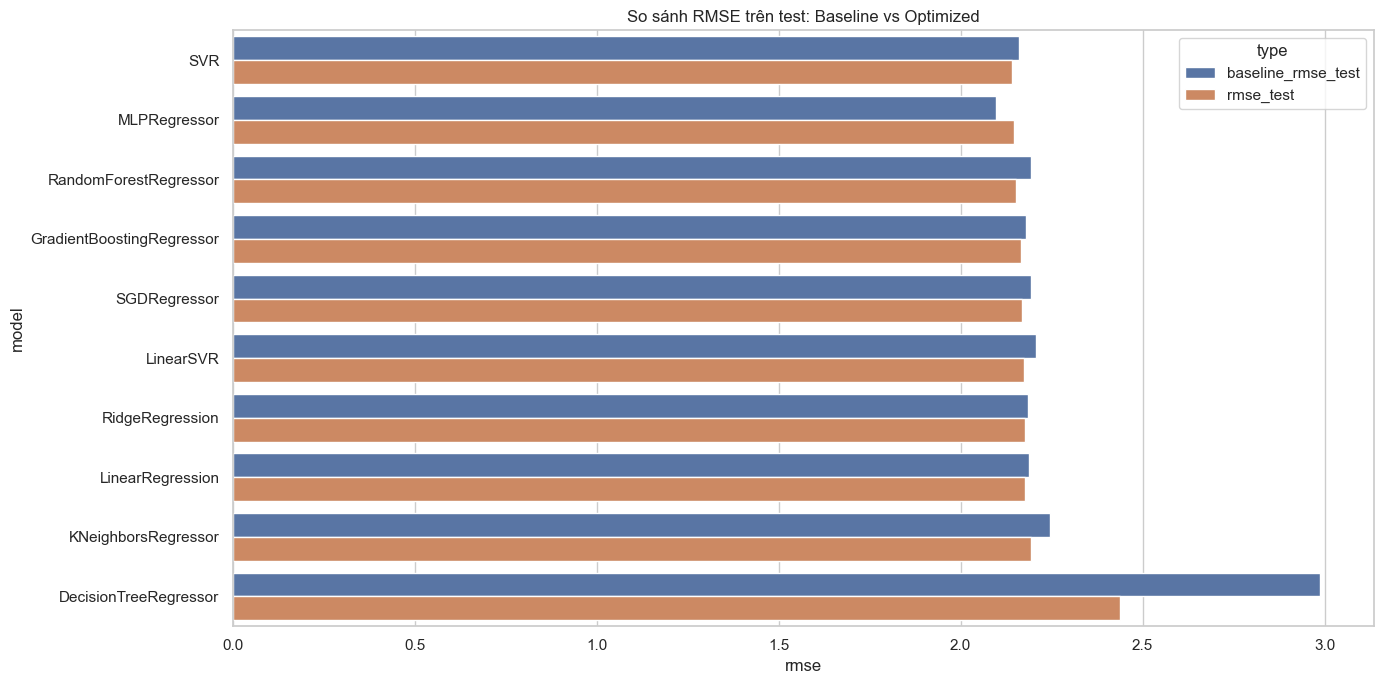

In [30]:
plot_compare_df = optimized_comparison_df[['model', 'baseline_rmse_test', 'rmse_test']].copy()
plot_compare_df = plot_compare_df.melt(id_vars='model', value_vars=['baseline_rmse_test', 'rmse_test'], var_name='type', value_name='rmse')

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_compare_df, x='rmse', y='model', hue='type')
plt.title('So sánh RMSE trên test: Baseline vs Optimized')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_vs_optimized_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

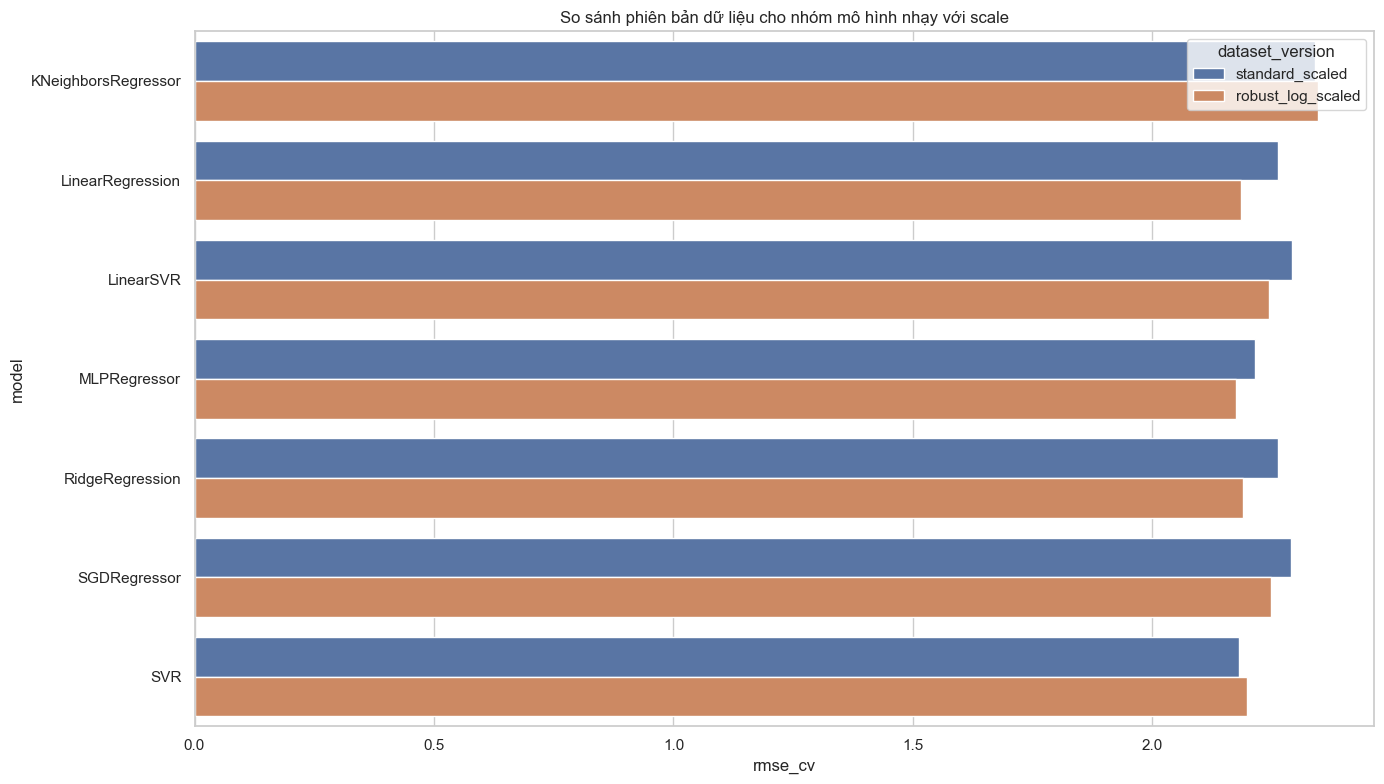

In [31]:
variant_plot_df = variant_results_df.copy()
plt.figure(figsize=(14, 8))
sns.barplot(data=variant_plot_df, x='rmse_cv', y='model', hue='dataset_version')
plt.title('So sánh phiên bản dữ liệu cho nhóm mô hình nhạy với scale')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'scaled_variant_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Lưu kết quả tối ưu hóa

In [32]:
variant_results_df.to_csv(METRICS_DIR / 'scaled_variant_comparison.csv', index=False)
optimized_cv_results_df.to_csv(METRICS_DIR / 'optimized_cv_results.csv', index=False)
optimized_test_results_df.to_csv(METRICS_DIR / 'optimized_test_results.csv', index=False)
optimized_oof_predictions.to_csv(METRICS_DIR / 'optimized_oof_predictions.csv', index=False)
optimized_test_predictions.to_csv(METRICS_DIR / 'optimized_test_predictions.csv', index=False)
optimized_comparison_df.to_csv(METRICS_DIR / 'baseline_vs_optimized_comparison.csv', index=False)
weighted_ensemble_results_df.to_csv(METRICS_DIR / 'weighted_ensemble_results.csv', index=False)
stacking_results_df.to_csv(METRICS_DIR / 'stacking_results.csv', index=False)
ensemble_summary_df.to_csv(METRICS_DIR / 'ensemble_summary_results.csv', index=False)

for model_name, artifact in optimized_artifacts.items():
    joblib.dump(artifact, MODELS_DIR / f'optimized_{model_name}.joblib')

joblib.dump({'model': meta_model, 'members': top3_models}, MODELS_DIR / 'optimized_stacking_ridge.joblib')

optimization_metadata = {
    'cv_strategy': {'type': 'KFold', 'n_splits': 5, 'shuffle': True, 'random_state': 42},
    'tuned_models': list(tuning_configs.keys()),
    'top3_models_for_ensemble': top3_models,
    'saved_metric_files': [
        'outputs/metrics/scaled_variant_comparison.csv',
        'outputs/metrics/optimized_cv_results.csv',
        'outputs/metrics/optimized_test_results.csv',
        'outputs/metrics/baseline_vs_optimized_comparison.csv',
        'outputs/metrics/weighted_ensemble_results.csv',
        'outputs/metrics/stacking_results.csv'
    ],
}

with open(METRICS_DIR / 'optimization_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(optimization_metadata, f, ensure_ascii=False, indent=2)

print('Đã lưu xong toàn bộ kết quả tối ưu hóa.')

Đã lưu xong toàn bộ kết quả tối ưu hóa.


## 15. Kết luận bước tối ưu hóa

- Tất cả 10 mô hình hồi quy bắt buộc đã được tuning bằng `RandomizedSearchCV`.
- Nhóm mô hình nhạy với scale đã được kiểm tra trên hai phiên bản dữ liệu khác nhau, giúp chọn đầu vào phù hợp hơn thay vì dùng một cấu hình cố định.
- Bảng `baseline vs optimized` cho phép chứng minh rõ ràng mức cải thiện sau tối ưu hóa.
- Hai chiến lược ensemble là `Weighted Average` và `StackingRidge` cung cấp thêm phương án nâng hiệu suất ngoài tuning đơn lẻ từng mô hình.
- Các kết quả trong notebook này là nền tảng chính để viết phần `Experiments and Discussion` trong báo cáo cuối cùng.

## 12. Tổng kết: baseline vs. optimized trên test



Dựa trên các file kết quả đã lưu:



- Trong [outputs/metrics/baseline_test_results.csv](../outputs/metrics/baseline_test_results.csv), mô hình baseline tốt nhất là **MLPRegressor (standard_scaled)** với `RMSE_test ≈ 2.097`.

- Trong [outputs/metrics/optimized_test_results.csv](../outputs/metrics/optimized_test_results.csv), mô hình optimized tốt nhất hiện tại là **SVR** với `RMSE_test ≈ 2.142`, tức là **chưa vượt được** baseline MLP trên tập test.

- Các ensemble như **Weighted Average** và **StackingRidge** trong [outputs/metrics/ensemble_summary_results.csv](../outputs/metrics/ensemble_summary_results.csv) cũng chỉ đạt `RMSE_test ≈ 2.11–2.13`, vẫn nhỉnh hơn baseline một chút về lỗi.



=> Về mặt **kỹ thuật**, bước tối ưu hóa đã giúp:



- Cải thiện điểm **cross-validation** cho một số mô hình so với baseline.

- Khám phá thêm các chiến lược kết hợp mô hình (ensemble).



Tuy nhiên, **trên tập test hiện tại**, baseline MLPRegressor vẫn là mô hình có `RMSE` nhỏ nhất.



> "Chúng em thử nhiều kỹ thuật tối ưu hóa (grid/random search, ensemble) nhưng trên tập test cụ thể này, mô hình baseline MLPRegressor vẫn cho kết quả tốt nhất. Do đó, mô hình cuối cùng được chọn để triển khai là baseline MLP, còn phần tối ưu hóa được xem là phân tích mở rộng và bài học về overfitting/khả năng generalization."